<h1 style="text-align:center;">ESCUELA POLITÉCNICA NACIONAL</h1>
<h2 style="text-align:center;">FACULTAD DE INGENIERÍA DE SISTEMAS</h2>
<h3 style="text-align:center;">INGENIERÍA EN CIENCIA DE LA COMPUTACION</h3>

**PERÍODO ACADÉMICO:** 2025-B  
**ASIGNATURA:** ICCD412 Métodos Numéricos  
**GRUPO:** GR1  
**Tarea 6**   
**ALUMNO:** Carrion Mauricio

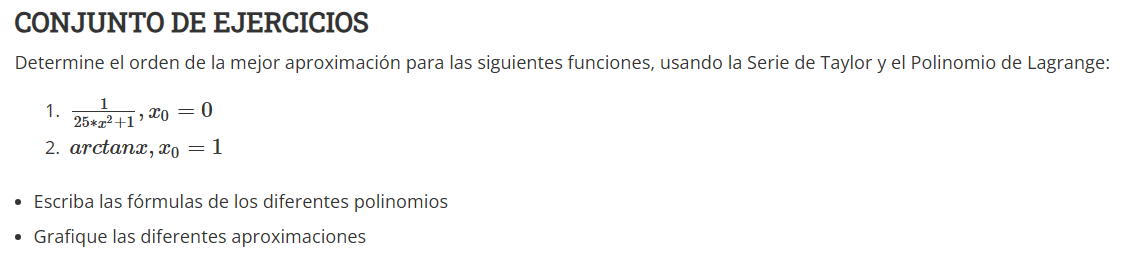

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable
import sympy as sym
from scipy.interpolate import lagrange

### Series de Taylor

In [4]:
def taylor_approx(fcn: Callable[[float], float], x0: float, n: int) -> sym.Symbol:
    x = sym.symbols("x")
    f = sym.sympify(fcn(x))
    taylor: sym.Symbol = 0
    for i in range(n + 1):
        term = f.diff(x, i).subs(x, x0) / sym.factorial(i) * (x - x0) ** i
        taylor += term
    return taylor

Usamos orden: $n = 3$, se mostrará el resultado de la función utilizando como parámetros la función original, $x_0$ y el orden del polinomio.

Quedando asi la primera funcion:

In [5]:
func = lambda x : 1 / (25*x*x + 1)
taylor_pol = taylor_approx(func, 0, 3)
taylor_pol

1 - 25*x**2

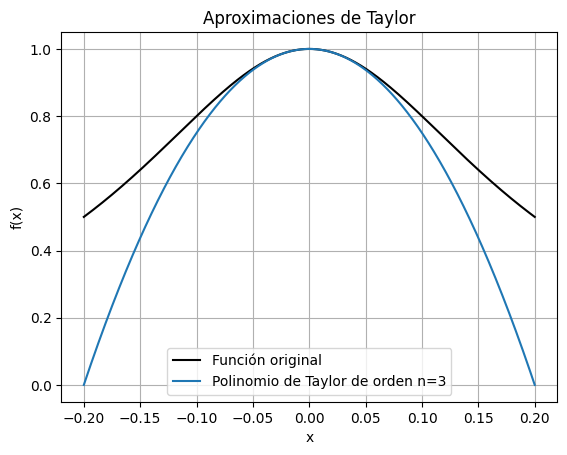

In [6]:
# Grafica de la funcion original y su aproximación de Taylor
def plot_taylor_approx(fcn: Callable[[float], float], taylor_poly, n: int, x_range: tuple):
    x = sym.symbols("x")
    x_vals = np.linspace(x_range[0], x_range[1], 1000)
    
    original_fcn = sym.lambdify(x, fcn(x), "numpy")
    y_vals = original_fcn(x_vals)
    plt.plot(x_vals, y_vals, label=f"Función original", color='black')
    
    taylor_fcn = sym.lambdify(x, taylor_poly, "numpy")
        
    taylor_y_vals = taylor_fcn(x_vals)
    if np.isscalar(taylor_y_vals):
        taylor_y_vals = np.full_like(x_vals, taylor_y_vals)
        
    plt.plot(x_vals, taylor_y_vals, label=f"Polinomio de Taylor de orden n={n}")
    
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Aproximaciones de Taylor")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_taylor_approx(func, taylor_pol, 3, (-0.2, 0.2))

Ahora para la segunda funcion:

In [7]:
func2 = lambda x : sym.atan(x)
taylor_pol = taylor_approx(func2, 1, 3)
taylor_pol

x/2 + (x - 1)**3/12 - (x - 1)**2/4 - 1/2 + pi/4

Y su función graficamente: 

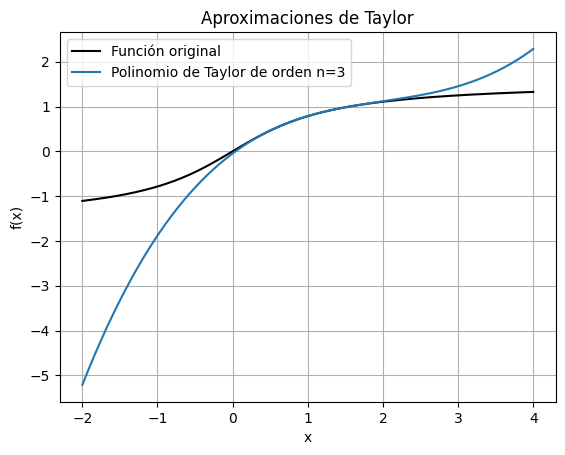

In [8]:
plot_taylor_approx(func2, taylor_pol, 3, (-2, 4))

### Polinomio de Lagrange

Es necesario más de un punto si queremos que funcione por ello tomaremos 3 puntos incluyendo el ya asignado como dato.

Calcula el polinomio de lagrange para la primera función

In [9]:
X = [-0.4, 0, 0.4]
Y = [0.2, 1, 0.2]

polynomial = lagrange(X, Y)
print(polynomial)

    2
-5 x + 1


Ahora se graficara la función original y su aproximación de Lagrange

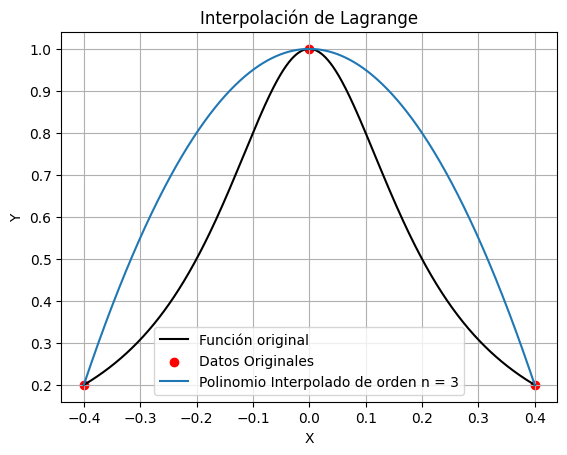

In [10]:
def plot_lagrange(fcn : Callable[[float], float], pol, n: int, x_range: tuple, X, Y):
    x = sym.symbols("x")
    x_vals = np.linspace(x_range[0], x_range[1], 1000)
    
    original_fcn = sym.lambdify(x, fcn(x), "numpy")
    y_vals = original_fcn(x_vals)
    plt.plot(x_vals, y_vals, label=f"Función original", color='black')
    
    x_values = np.linspace(x_range[0], x_range[1], 1000)
    y_values = polynomial(x_values)

    plt.scatter(X, Y, color='red', label='Datos Originales')
    plt.plot(x_values, y_values, label=f'Polinomio Interpolado de orden n = {n}')
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Interpolación de Lagrange')
    plt.legend()
    plt.grid(True)
    plt.show
    
plot_lagrange(func, polynomial, 3, (-0.4, 0.4), X, Y)

Y ahora para la segunda funcion representamos algunos valores o pares ordenados de la propia función original para usar el polinomio de lagrange:

         2
-0.2315 x + 1.017 x


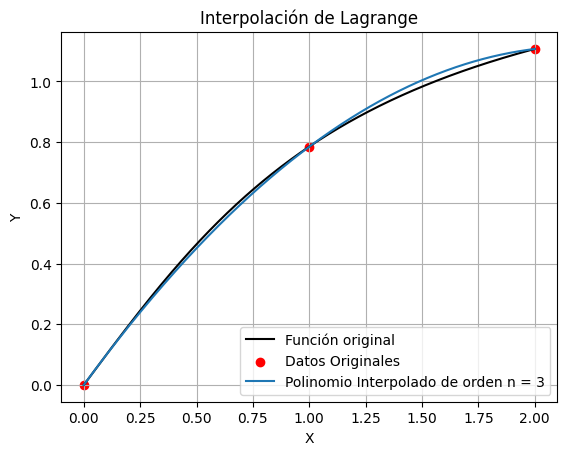

In [11]:
X = [0, 1, 2]
Y = [0, 0.785, 1.107]

polynomial = lagrange(X, Y)
print(polynomial)

plot_lagrange(func2, polynomial, 3, (0, 2), X, Y)